# Proyek Analisis Data: Bike Sharing Dataset https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
- **Nama:** [InisialA]
- **Email:** [YNTKTSY]
- **ID Dicoding:** [BEBAN]

## Menentukan Pertanyaan Bisnis
- **Pertanyaan 1:** Sejauh mana fluktuasi musim dan tingkat keburukan cuaca memengaruhi tren naik-turunnya volume penyewaan sepeda secara keseluruhan setiap harinya?
- **Pertanyaan 2:** Bagaimana perbedaan pola penyewaan antara pengguna terdaftar dan pengguna kasual  pada hari kerja dibandingkan dengan akhir pekan/hari libur?

## Import Semua Packages/Library yang Digunakan

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import shutil

sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

In [26]:
DATA_DIR = "data"
DASHBOARD_DIR = "dashboard"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(DASHBOARD_DIR, exist_ok=True)

cache_path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")
print("Dataset terunduh di cache:", cache_path)

shutil.copy(os.path.join(cache_path, "day.csv"), os.path.join(DATA_DIR, "day.csv"))
shutil.copy(os.path.join(cache_path, "hour.csv"), os.path.join(DATA_DIR, "hour.csv"))
print("Dataset berhasil disalin ke folder 'data/'")

day_df = pd.read_csv(os.path.join(DATA_DIR, "day.csv"))
hour_df = pd.read_csv(os.path.join(DATA_DIR, "hour.csv"))

day_df.head()

Dataset terunduh di cache: /home/ardd/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Dataset berhasil disalin ke folder 'data/'


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset memuat rekam jejak penyewaan sepeda harian yang dimulai dari tanggal 1 Januari 2011 (`dteday`), dengan musim dingin (`season` 1) sebagai titik awal pencatatan.
- Total penyewaan sepeda harian (`cnt`) merupakan akumulasi dari dua tipe pelanggan: pengguna biasa (`casual`) dan pengguna terdaftar (`registered`). 
- Dari 5 baris pertama, terlihat sekilas bahwa pengguna `registered` jauh mendominasi jumlah penyewaan, terutama saat memasuki hari kerja (`workingday` bernilai 1) di mana angkanya melonjak signifikan dibandingkan akhir pekan.
- Fitur terkait cuaca seperti suhu (`temp`, `atemp`), kelembapan (`hum`), dan kecepatan angin (`windspeed`) sudah berada dalam format yang dinormalisasi (skala rasio desimal).

### Assessing Data

In [27]:
print("--- Info day_df ---")
day_df.info()

print("\n--- Missing Values day_df ---")
print(day_df.isna().sum())

print("\n--- Duplicates day_df ---")
print("Jumlah duplikasi: ", day_df.duplicated().sum())

print("\n--- Descriptive Statistics day_df ---")
display(day_df.describe())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Missing Values day_df ---
instant       0
dteday        0
season    

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- **Kelengkapan Data:** Dataset memiliki total 731 entri harian yang utuh. Tidak ditemukan adanya *missing values* (nilai kosong) pada seluruh kolom, dan tidak ada baris data yang terduplikasi (jumlah duplikasi: 0).
- **Penyesuaian Tipe Data:** Kolom `dteday` (tanggal) saat ini memiliki tipe data `object` (string). Kolom ini harus dikonversi menjadi tipe data `datetime` untuk memungkinkan analisis berbasis waktu (*time-series*).
- **Representasi Kategori:** Variabel kategorik seperti `season`, `weathersit`, `holiday`, `workingday`, dan `weekday` saat ini masih direpresentasikan dalam bentuk angka (*integer*). Nilai-nilai ini perlu dipetakan (*mapping*) menjadi label teks yang deskriptif (misalnya: season 1 menjadi 'Springer') agar interpretasi data dan visualisasi nantinya lebih mudah dipahami.
- **Karakteristik Variabel Numerik:** Berdasarkan ringkasan statistik, fitur yang berkaitan dengan cuaca (`temp`, `atemp`, `hum`, `windspeed`) sudah berada dalam format yang dinormalisasi, terlihat dari nilai minimum dan maksimumnya yang berada di rentang 0 hingga kurang dari 1.
- **Fluktuasi Permintaan:** Kolom target total penyewaan (`cnt`) memiliki rentang variansi yang sangat lebar. Penyewaan harian terendah tercatat hanya 22 unit, sementara tertingginya bisa menembus 8.714 unit, dengan rata-rata harian di angka 4.504 unit. Hal ini mengindikasikan adanya faktor eksternal yang sangat memengaruhi minat sewa pelanggan.

### Cleaning Data

In [28]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

season_mapping = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_mapping = {1: "Clear/Partly Cloudy", 2: "Misty/Cloudy", 3: "Light Snow/Rain", 4: "Heavy Rain/Snow"}
workingday_mapping = {0: "Weekend/Holiday", 1: "Working Day"}

day_df["season_label"] = day_df["season"].map(season_mapping)
day_df["weather_label"] = day_df["weathersit"].map(weather_mapping)
day_df["workingday_label"] = day_df["workingday"].map(workingday_mapping)

export_path = os.path.join(DASHBOARD_DIR, "main_data.csv")
day_df.to_csv(export_path, index=False)

print("--- Info Tipe Data Kolom Target ---")
print(day_df[['dteday', 'season_label', 'weather_label', 'workingday_label']].dtypes)

print("\n--- 5 Baris Pertama Hasil Transformasi ---")
display(day_df[['dteday', 'season_label', 'weather_label', 'workingday_label']].head())

print(f"\nStatus: Data cleaning completed and exported to {export_path}")

--- Info Tipe Data Kolom Target ---
dteday              datetime64[ns]
season_label                object
weather_label               object
workingday_label            object
dtype: object

--- 5 Baris Pertama Hasil Transformasi ---


,dteday,season_label,weather_label,workingday_label
0,2011-01-01,Spring,Misty/Cloudy,Weekend/Holiday
1,2011-01-02,Spring,Misty/Cloudy,Weekend/Holiday
2,2011-01-03,Spring,Clear/Partly Cloudy,Working Day
3,2011-01-04,Spring,Clear/Partly Cloudy,Working Day
4,2011-01-05,Spring,Clear/Partly Cloudy,Working Day



Status: Data cleaning completed and exported to dashboard/main_data.csv


**Insight:**
- Proses transformasi data telah dieksekusi dengan hasil yang terlihat pada *output* di atas: tipe data pada kolom `dteday` terkonfirmasi sudah berubah dari `object` menjadi `datetime64[ns]`.
- Dataset kini memiliki tiga kolom tambahan yang bersifat representatif (`season_label`, `weather_label`, dan `workingday_label`). Label teks ini akan sangat krusial untuk menjaga integritas dan kemudahan interpretasi desain saat melakukan *Explanatory Analysis* menggunakan visualisasi data.
- Dataset yang telah bersih dan terstruktur (*cleaned data*) berhasil diekspor menjadi berkas `main_data.csv`. File terpisah ini dikhususkan sebagai basis data utama (*data source*) agar performa saat *deploy* dashboard interaktif menggunakan Streamlit Cloud nanti lebih ringan dan stabil.

## Exploratory Data Analysis (EDA)

### Explore ...

In [29]:
rental_by_season = day_df.groupby("season_label")["cnt"].sum().reset_index().sort_values(by="cnt", ascending=False)
rental_by_weather = day_df.groupby("weather_label")["cnt"].sum().reset_index().sort_values(by="cnt", ascending=False)

user_type_workingday = day_df.groupby("workingday_label")[["casual", "registered"]].mean().reset_index()

display(rental_by_season)
display(user_type_workingday)

,season_label,cnt
0,Fall,1061129
2,Summer,918589
3,Winter,841613
1,Spring,471348


,workingday_label,casual,registered
0,Weekend/Holiday,1371.134199,2959.034632
1,Working Day,606.570000,3978.250000


**Insight:**
- Musim Gugur (Fall) memiliki jumlah penyewaan tertinggi, sedangkan Musim Semi (Spring) terendah.
- Pengguna terdaftar (registered) mendominasi penyewaan pada hari kerja, sedangkan rata-rata pengguna kasual (casual) meningkat signifikan saat akhir pekan/hari libur.`

## Visualization & Explanatory Analysis

### Pertanyaan 1: 
### Sejauh mana fluktuasi musim dan tingkat keburukan cuaca memengaruhi tren naik-turunnya volume penyewaan sepeda secara keseluruhan setiap harinya?

/tmp/ipykernel_22675/3275805167.py:8: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/tmp/ipykernel_22675/3275805167.py:30: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


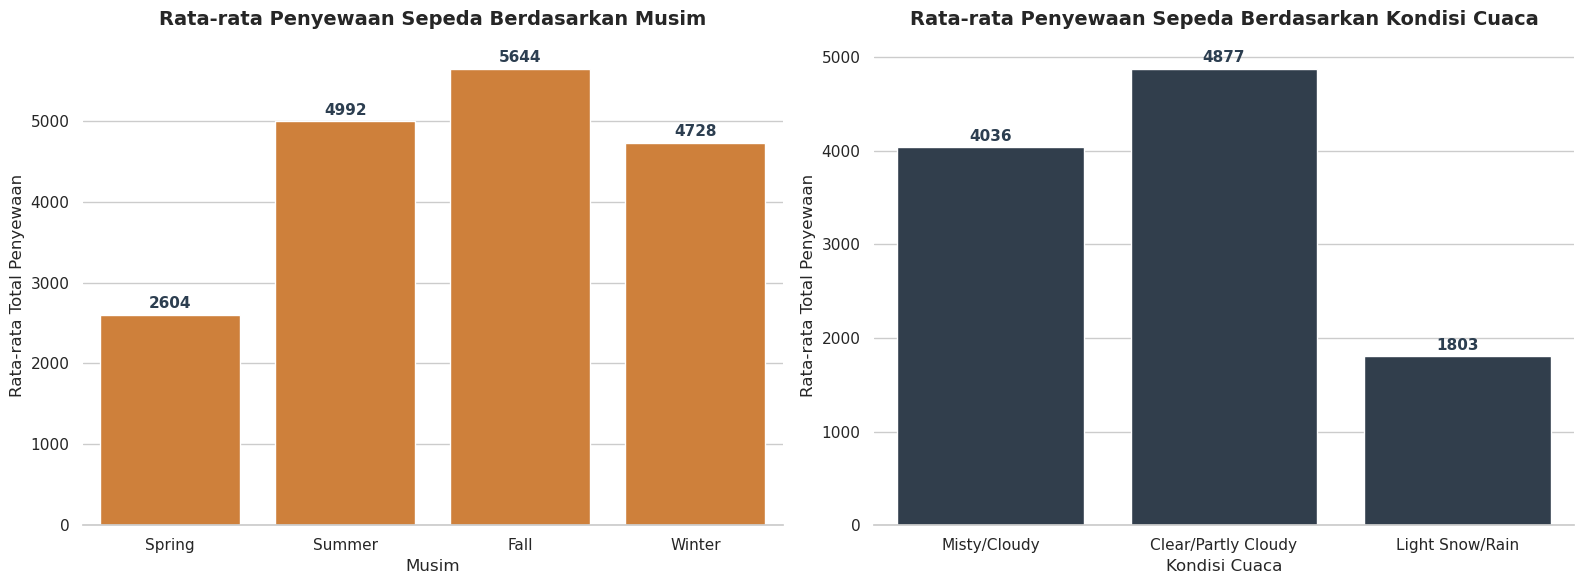

In [30]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

season_colors = ['#E67E22'] 
weather_colors = ['#2C3E50']

sns.barplot(
    ax=axes[0], 
    data=day_df, 
    x="season_label", 
    y="cnt", 
    palette=season_colors, 
    hue="season_label",
    legend=False,
    errorbar=None
)
axes[0].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Musim", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Musim", fontsize=12)
axes[0].set_ylabel("Rata-rata Total Penyewaan", fontsize=12)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 8), 
                     textcoords='offset points',
                     fontsize=11, color='#2C3E50', fontweight='bold')

sns.barplot(
    ax=axes[1], 
    data=day_df, 
    x="weather_label", 
    y="cnt", 
    palette=weather_colors, 
    hue="weather_label",
    legend=False,
    errorbar=None
)
axes[1].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Kondisi Cuaca", fontsize=12)
axes[1].set_ylabel("Rata-rata Total Penyewaan", fontsize=12)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.0f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 8), 
                         textcoords='offset points',
                         fontsize=11, color='#2C3E50', fontweight='bold')

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

### Pertanyaan 2:
### Bagaimana perbedaan pola penyewaan antara pengguna terdaftar dan pengguna kasual  pada hari kerja dibandingkan dengan akhir pekan/hari libur?

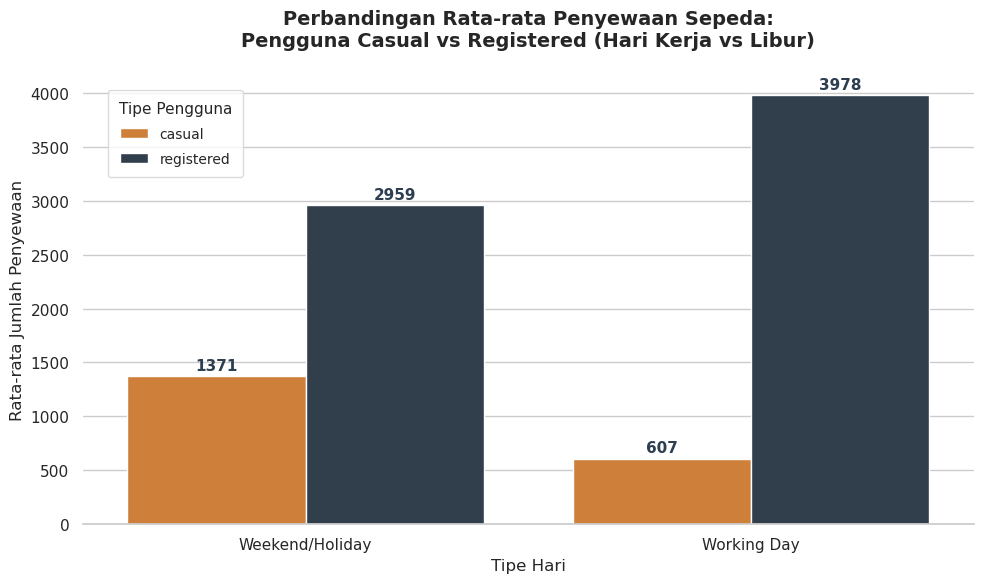

In [31]:
melted_df = pd.melt(
    day_df, 
    id_vars=['workingday_label'], 
    value_vars=['casual', 'registered'], 
    var_name='User Type', 
    value_name='Average Rentals'
)

sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(10, 6))

custom_palette = {"registered": "#2C3E50", "casual": "#E67E22"}

ax = sns.barplot(
    data=melted_df, 
    x="workingday_label", 
    y="Average Rentals", 
    hue="User Type", 
    palette=custom_palette, 
    errorbar=None
)

plt.title("Perbandingan Rata-rata Penyewaan Sepeda:\nPengguna Casual vs Registered (Hari Kerja vs Libur)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Tipe Hari", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)

plt.legend(
    title="Tipe Pengguna", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper left',             
    bbox_to_anchor=(0.02, 0.98),  
    frameon=True,                 
    facecolor='white',            
    edgecolor='lightgray',       
    labelspacing=0.8,             
    borderpad=0.8               
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=11, color='#2C3E50', fontweight='bold')

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

**Insight :**

- **Pengaruh Musim:** Fluktuasi musim memiliki dampak yang sangat signifikan terhadap volume penyewaan. Musim Gugur (*Fall*) menjadi puncak tertinggi rata-rata penyewaan sepeda, disusul oleh Musim Panas (*Summer*). Sebaliknya, permintaan anjlok ke titik terendah pada Musim Semi (*Spring*), yang pada dataset ini mewakili bulan-bulan awal tahun dengan suhu yang masih sangat dingin.
- **Pengaruh Kondisi Cuaca:** Tren penyewaan berbanding lurus dengan kecerahan cuaca. Cuaca yang cerah atau sedikit berawan (*Clear/Partly Cloudy*) mendatangkan volume penyewaan maksimal. Semakin buruk cuacanya (seperti *Misty/Cloudy* atau *Light Snow/Rain*), semakin drastis pula penurunan jumlah penyewaan.
- **Kesimpulan Bisnis:** Kondisi lingkungan sangat mendikte perilaku pelanggan. Penyewaan sepeda adalah bisnis yang sangat musiman (*seasonal*). Perusahaan harus memaksimalkan ketersediaan sepeda dan strategi pemasaran pada cuaca cerah di musim panas hingga musim gugur, serta merencanakan efisiensi operasional (seperti perawatan/servis armada) pada musim dingin/semi saat permintaan sedang lesu.

- **Pola Pengguna Terdaftar (*Registered*):** Pengguna terdaftar menunjukkan volume penyewaan yang jauh lebih tinggi pada **Hari Kerja (*Working Day*)** dibandingkan pada akhir pekan/hari libur. Hal ini mengindikasikan bahwa sebagian besar pengguna *registered* memanfaatkan sepeda sewaan sebagai moda transportasi komuter harian yang rutin (misalnya untuk pergi ke kantor atau kampus).
- **Pola Pengguna Kasual (*Casual*):** Sebaliknya, pengguna kasual menunjukkan tren yang berlawanan. Rata-rata penyewaan oleh pengguna kasual justru meningkat tajam dan mencapai puncaknya pada **Akhir Pekan/Hari Libur (*Weekend/Holiday*)**. Ini menunjukkan bahwa demografi pengguna kasual lebih cenderung menyewa sepeda untuk tujuan rekreasi, olahraga santai, atau pariwisata.
- **Kesimpulan Bisnis:** Terdapat perbedaan motif penggunaan yang sangat jelas antara kedua kelompok. Untuk meningkatkan *revenue*, perusahaan dapat memberlakukan strategi harga dinamis (*dynamic pricing*). Misalnya, menawarkan paket langganan komuter bulanan yang menarik untuk mempertahankan pengguna *registered* di hari kerja, serta meluncurkan promo "Tiket Wisata Akhir Pekan" untuk menarik lebih banyak pengguna *casual* di hari libur.

## Analisis Lanjutan (Opsional)

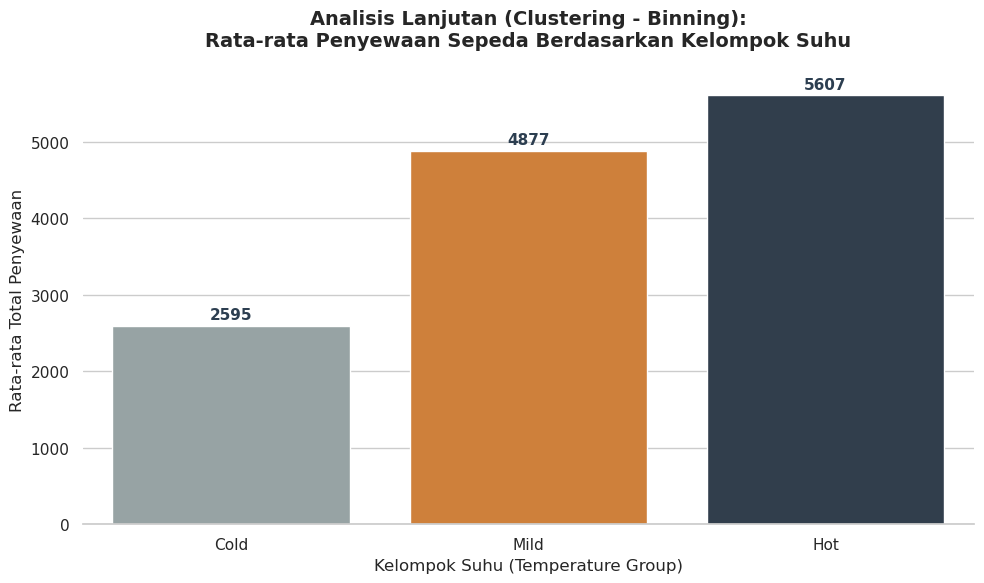

In [32]:
bins = [0, 0.33, 0.66, 1.0]
labels = ['Cold', 'Mild', 'Hot']

day_df['temp_group'] = pd.cut(day_df['temp'], bins=bins, labels=labels, include_lowest=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(10, 6))

temp_colors = ['#95A5A6', '#E67E22', '#2C3E50']

ax = sns.barplot(
    data=day_df, 
    x='temp_group', 
    y='cnt', 
    palette=temp_colors, 
    hue='temp_group',
    legend=False,
    errorbar=None
)

plt.title("Analisis Lanjutan (Clustering - Binning):\nRata-rata Penyewaan Sepeda Berdasarkan Kelompok Suhu", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Kelompok Suhu (Temperature Group)", fontsize=12)
plt.ylabel("Rata-rata Total Penyewaan", fontsize=12)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=11, color='#2C3E50', fontweight='bold')

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

## Conclusion

- **Conclusion Pertanyaan 1:** Kondisi lingkungan (musim dan cuaca) terbukti memiliki korelasi yang sangat kuat terhadap tingkat permintaan penyewaan sepeda, menegaskan bahwa model bisnis ini bersifat *highly seasonal*. Berdasarkan hasil analisis, puncak volume penyewaan terjadi secara konsisten pada **Musim Gugur (*Fall*)** dan **Musim Panas (*Summer*)**, khususnya ketika kondisi cuaca sedang cerah atau sedikit berawan (*Clear/Partly Cloudy*). Sebaliknya, kondisi cuaca ekstrem (seperti hujan lebat atau salju) dan Musim Semi (*Spring* - yang secara historis bersuhu dingin di awal tahun) memicu penurunan drastis pada minat pengguna. Oleh karena itu, strategi penempatan armada maksimal dan kampanye pemasaran utama harus difokuskan pada pertengahan hingga akhir tahun.

- **Conclusion Pertanyaan 2:** Terdapat segmentasi perilaku pelanggan yang sangat kontras berdasarkan tipe hari. Mayoritas pengguna **Terdaftar (*Registered*)** menunjukkan lonjakan aktivitas pada **Hari Kerja (*Working Day*)**, yang mengindikasikan bahwa kelompok ini adalah komuter yang bergantung pada layanan sepeda untuk rutinitas mobilitas harian (seperti berangkat ke kantor atau kampus). Di sisi lain, pengguna **Kasual (*Casual*)** justru mencetak angka penyewaan tertinggi pada **Akhir Pekan/Hari Libur (*Weekend/Holiday*)**, merepresentasikan motivasi penggunaan yang lebih condong pada rekreasi atau pariwisata. Pemahaman profil ini membuka peluang untuk menerapkan strategi harga dinamis (*dynamic pricing*), seperti menawarkan paket langganan komuter bulanan untuk pekerja, dan meluncurkan promo rekreasi akhir pekan khusus untuk mengonversi pengguna kasual.